<a href="https://colab.research.google.com/github/sumyuck/ML-learning/blob/main/ml/ML_p_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
With Libraries
```



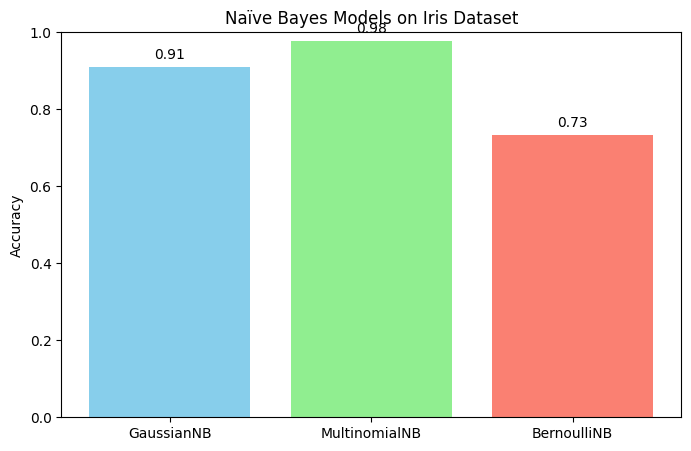

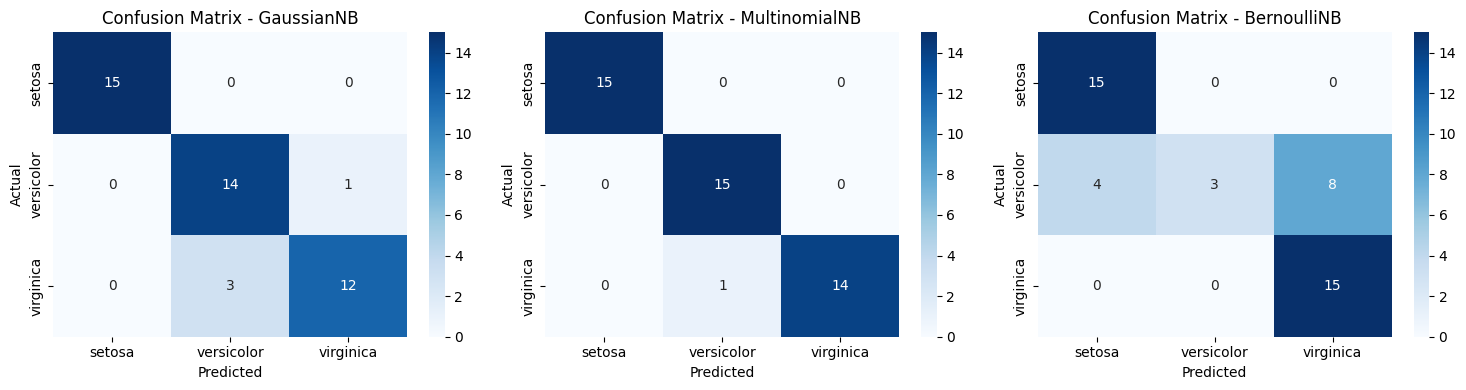

=== GaussianNB Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45


=== MultinomialNB Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45


=== BernoulliNB Classification Report ===
              precision    recall  f1-score   support

      setosa       0.79      1.00      0.88        15


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns #CF
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Gaussian Naive Bayes

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
acc_gnb = accuracy_score(y_test, y_pred_gnb)
report_gnb = classification_report(y_test, y_pred_gnb, target_names=iris.target_names)

# Multinomial Naive Bayes

mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)
acc_mnb = accuracy_score(y_test, y_pred_mnb)
report_mnb = classification_report(y_test, y_pred_mnb, target_names=iris.target_names)

X_train_bin = (X_train > np.median(X_train, axis=0)).astype(int)
X_test_bin = (X_test > np.median(X_train, axis=0)).astype(int)

# Bernoulli Naive Bayes

bnb = BernoulliNB()
bnb.fit(X_train_bin, y_train)
y_pred_bnb = bnb.predict(X_test_bin)
acc_bnb = accuracy_score(y_test, y_pred_bnb)
report_bnb = classification_report(y_test, y_pred_bnb, target_names=iris.target_names)

models = ['GaussianNB', 'MultinomialNB', 'BernoulliNB']
accuracies = [acc_gnb, acc_mnb, acc_bnb]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=['skyblue','lightgreen','salmon'])
plt.title("Naïve Bayes Models on Iris Dataset")
plt.ylabel("Accuracy")
plt.ylim(0,1)
for i, acc in enumerate(accuracies):
    plt.text(i, acc+0.02, f"{acc:.2f}", ha='center', fontsize=10)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, preds, title in zip(
    axes,
    [y_pred_gnb, y_pred_mnb, y_pred_bnb],
    ['GaussianNB', 'MultinomialNB', 'BernoulliNB']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=iris.target_names,
                yticklabels=iris.target_names, ax=ax)
    ax.set_title(f"Confusion Matrix - {title}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

print("=== GaussianNB Classification Report ===")
print(report_gnb)
print("\n=== MultinomialNB Classification Report ===")
print(report_mnb)
print("\n=== BernoulliNB Classification Report ===")
print(report_bnb)



```
Without Libraries
```



In [ ]:
import csv, math, random

def load_iris(path="Iris.csv"):
    X, y = [], []
    with open(path) as f:
        r = csv.DictReader(f)
        feats = [c for c in r.fieldnames if c not in ("Id","Species")]
        for row in r:
            X.append([float(row[c]) for c in feats]); y.append(row["Species"])
    return X, y

def stratified_split(X, y, test_size=0.3, seed=42):
    random.seed(seed)
    idx = {}
    for i, c in enumerate(y): idx.setdefault(c, []).append(i)
    tr, te = [], []
    for c, ids in idx.items():
        random.shuffle(ids)
        k = max(1, round(len(ids)*test_size))
        te += ids[:k]; tr += ids[k:]
    random.shuffle(tr); random.shuffle(te)
    Xtr=[X[i] for i in tr]; Ytr=[y[i] for i in tr]
    Xte=[X[i] for i in te]; Yte=[y[i] for i in te]
    return Xtr, Xte, Ytr, Yte

def labels_in_order(y):
    seen=set(); out=[]
    for v in y:
        if v not in seen: seen.add(v); out.append(v)
    return out

def acc(y, p): return sum(a==b for a,b in zip(y,p))/len(y)
def cmatrix(y, p, labels):
    L={c:i for i,c in enumerate(labels)}
    m=[[0]*len(labels) for _ in labels]
    for a,b in zip(y,p): m[L[a]][L[b]]+=1
    return m

# --- Gaussian NB ---
class GNB:
    def __init__(self, eps=1e-9): self.eps=eps
    def fit(self, X, y):
        self.C = labels_in_order(y); n=len(X[0]); N=len(X)
        grp={c:[] for c in self.C}
        for xi,yi in zip(X,y): grp[yi].append(xi)
        self.prior={c:len(grp[c])/N for c in self.C}
        self.mu={}; self.var={}
        for c in self.C:
            cols=list(zip(*grp[c]))
            self.mu[c]=[sum(col)/len(col) for col in cols]
            self.var[c]=[ (sum((v-m)**2 for v in col)/max(1,len(col)-1))+self.eps
                          for col,m in zip(cols,self.mu[c]) ]
        return self
    def pred_one(self, x):
        best=None; bv=-1e9
        for c in self.C:
            s=math.log(self.prior[c])
            for xj,m,v in zip(x,self.mu[c],self.var[c]):
                s += -0.5*(math.log(2*math.pi*v)+((xj-m)**2)/v)
            if s>bv: bv=s; best=c
        return best
    def predict(self, X): return [self.pred_one(x) for x in X]

# --- Multinomial NB ---
class MNB:
    def __init__(self, alpha=1.0): self.a=alpha
    def fit(self, X, y):
        self.C = labels_in_order(y); d=len(X[0]); N=len(X)
        grp={c:[] for c in self.C}
        for xi,yi in zip(X,y): grp[yi].append([max(0.0,v) for v in xi])
        self.prior={c:len(grp[c])/N for c in self.C}
        self.logp={}
        for c in self.C:
            s=[0.0]*d
            for r in grp[c]:
                for j,v in enumerate(r): s[j]+=v
            tot=sum(s); den=tot+self.a*d
            self.logp[c]=[math.log((s[j]+self.a)/den) for j in range(d)]
        return self
    def pred_one(self, x):
        x=[max(0.0,v) for v in x]
        best=None; bv=-1e9
        for c in self.C:
            s=math.log(self.prior[c]) + sum(xj*lp for xj,lp in zip(x,self.logp[c]))
            if s>bv: bv=s; best=c
        return best
    def predict(self, X): return [self.pred_one(x) for x in X]

# --- Bernoulli NB ---
class BNB:
    def __init__(self, alpha=1.0): self.a=alpha
    def fit(self, X, y):
        self.C = labels_in_order(y); d=len(X[0]); N=len(X)

        cols=list(zip(*X))
        thr=[]
        for col in cols:
            s=sorted(col); n=len(s)
            thr.append(s[n//2] if n%2 else 0.5*(s[n//2-1]+s[n//2]))
        self.thr=thr
        def binarize(row): return [1 if row[j]>thr[j] else 0 for j in range(d)]
        Xb=[binarize(r) for r in X]
        grp={c:[] for c in self.C}
        for xb,yi in zip(Xb,y): grp[yi].append(xb)
        self.prior={c:len(grp[c])/N for c in self.C}
        self.p={}
        for c in self.C:
            ones=[0]*d
            for r in grp[c]:
                for j,v in enumerate(r): ones[j]+=v
            den=len(grp[c])+2*self.a
            self.p[c]=[(ones[j]+self.a)/den for j in range(d)]
        return self
    def _bin(self, x): return [1 if x[j]>self.thr[j] else 0 for j in range(len(x))]
    def pred_one(self, x):
        xb=self._bin(x); best=None; bv=-1e9
        for c in self.C:
            s=math.log(self.prior[c])
            for j,bj in enumerate(xb):
                p=self.p[c][j]; s+=math.log(p if bj else (1-p))
            if s>bv: bv=s; best=c
        return best
    def predict(self, X): return [self.pred_one(x) for x in X]

if __name__ == "__main__":
    X,y = load_iris()
    Xtr,Xte,Ytr,Yte = stratified_split(X,y,0.3,42)
    labels = labels_in_order(y)

    g = GNB().fit(Xtr,Ytr); pg = g.predict(Xte)
    m = MNB().fit(Xtr,Ytr); pm = m.predict(Xte)
    b = BNB().fit(Xtr,Ytr); pb = b.predict(Xte)

    print(f"GaussianNB  acc: {acc(Yte,pg):.3f}")
    print(f"Multinomial  acc: {acc(Yte,pm):.3f}")
    print(f"Bernoulli    acc: {acc(Yte,pb):.3f}")

    for name, pred in [("GaussianNB",pg), ("Multinomial",pm), ("Bernoulli",pb)]:
        cm = cmatrix(Yte,pred,labels)
        print(f"\nConfusion Matrix — {name}")
        print("            "+" ".join(f"{l:>12}" for l in labels))
        for i,row in enumerate(cm):
            print(f"{labels[i]:>12} "+" ".join(f"{v:12d}" for v in row))


GaussianNB  acc: 0.956
Multinomial  acc: 0.978
Bernoulli    acc: 0.644

Confusion Matrix — GaussianNB
                       0            1            2
           0           15            0            0
           1            0           15            0
           2            0            2           13

Confusion Matrix — Multinomial
                       0            1            2
           0           15            0            0
           1            0           14            1
           2            0            0           15

Confusion Matrix — Bernoulli
                       0            1            2
           0           15            0            0
           1            6            2            7
           2            0            3           12
